In [271]:
import numpy as np
import csv
from scipy import signal
import matplotlib.pyplot as plt

In [272]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

Ymeas = cargar_dataset("Ymeas.txt")
N = len(Ymeas)
#salida -= np.mean(salida)
print(Ymeas.shape)

(1000,)


In [273]:
class MinimosCuadrados():
    def __init__(self):
        pass
    
    def fit(self, T, y):
        # T: features x 1
        # y: datos x 1
        if T.ndim < 2:
            T = T.reshape((T.shape[0], 1))
        if y.ndim < 2:
            y = y.reshape((y.shape[0], 1))
        self.H = np.linalg.inv(T.T @ T) @ T.T @ y

    def transform(self, T):
        if T.ndim < 2:
            T = T.reshape((T.shape[0], 1))

        salida = T @ self.H
        return salida

In [274]:
MC = MinimosCuadrados()
T = np.arange(1, len(Ymeas) + 1, 1)

MC.fit(T, Ymeas)

Yrec = MC.transform(T)

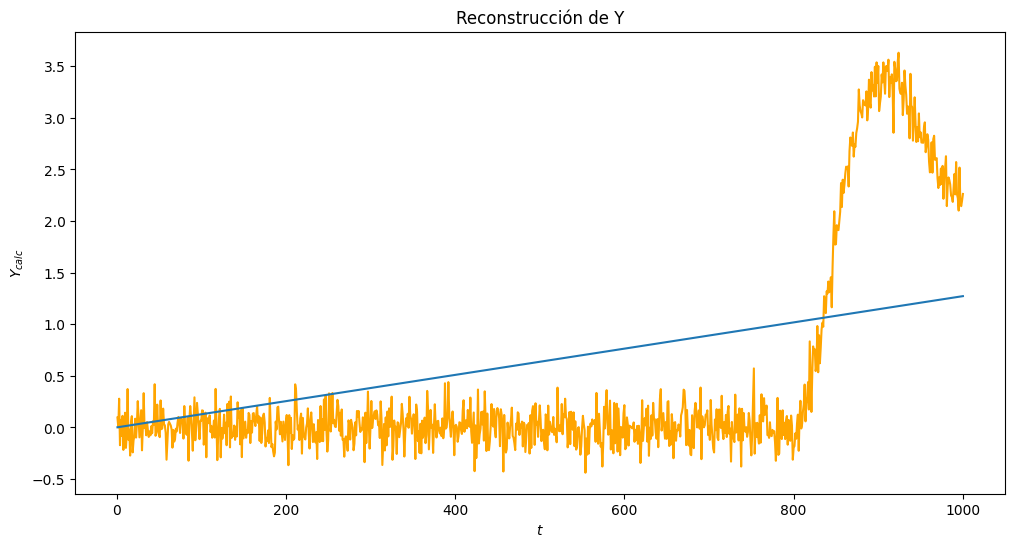

In [275]:
plt.figure(figsize=(12,6))
plt.title("Reconstrucción de Y")
plt.xlabel("$t$")
plt.ylabel("$Y_{calc}$")
plt.plot(T, Ymeas, color="orange")
plt.plot(T, Yrec)

In [276]:
b = 4.0  # Damping constant
k = 2.0  # Stiffness of the spring
m = 20.0  # Mass
# F = 5.0  # Force
Ac = np.array([[0.0, 1.0], [-k / m, -b / m]])
Bc = np.array([[0.0], [1.0 / m]])
Cc = np.array([[1.0, 0.0]])
Dc = 0

dt = 0.1  # seconds      

(Ad, Bd, Cd, Dd, _) = signal.cont2discrete((Ac, Bc, Cc, Dc), dt, method='zoh', alpha=None)

print(Ad, Bd, Cd, Dd)

Nsim = 1000

Nx = 2
Ny = 1
Nu = 1

Usim = np.ones((Nsim, Nu)) * 0.0
Usim[800:] = 5.0



[[ 0.99950336  0.09899013]
 [-0.00989901  0.97970533]] [[0.00024832]
 [0.00494951]] [[1. 0.]] 0


In [277]:
k = Nsim 

HU = np.zeros((k,1))
Gamma = np.zeros((k, Nx))

for i in range(k):
    Gamma[i, :] = (Cd @ np.linalg.matrix_power(Ad, i)).reshape(-1)

for i in range(k):
    suma = 0
    for j in range(i):
        u_j = Usim[j,0]
        suma += Cd @ np.linalg.matrix_power(Ad, i-1-j) @ Bd * u_j 
    HU[i] = suma 

Ytilde = Ymeas[:k].reshape((k,1)) - HU

MC = MinimosCuadrados()
MC.fit(Gamma, Ytilde)
x0_est = MC.H # Esto está medio incheckeable
print(x0_est)
y_rec = MC.transform(Gamma)


[[-0.01255184]
 [ 0.00474779]]


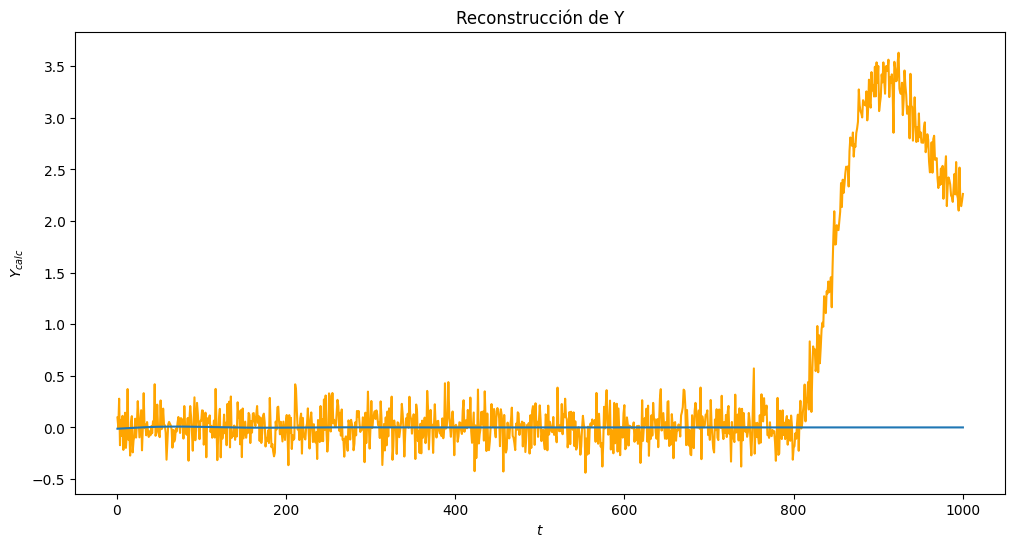

In [278]:
plt.figure(figsize=(12,6))
plt.title("Reconstrucción de Y")
plt.xlabel("$t$")
plt.ylabel("$Y_{calc}$")
plt.plot(T, Ymeas, color="orange")
plt.plot(T, y_rec)

In [279]:
print(f"Ymeas_0: {Ymeas[0]}")
print(f"Y_0: {Yrec[0]}")

Ymeas_0: 0.0958591220852272
Y_0: [0.00127215]
